# cleaning + blink mask + optional interpolation + trial exclusion + logging


For each trial:
	•	marks invalid right-eye samples if NaN, ≤0, or outside [min,max] (and optionally low tracking ratio)
	•	interpolates short gaps (blink-like) up to max_interp_gap_ms
	•	excludes the trial if
	•	invalid fraction > exclude_if_invalid_frac_gt, OR
	•	baseline window (first 500 ms) has fewer than min_valid_baseline_samples valid samples
	•	logs everything to a CSV

In [21]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import pandas as pd
import numpy as np


@dataclass
class CleanConfig:
    trial_col: str = "trial"
    time_col: str = "time_ms"
    time_rel_col: str = "t_rel_ms"
    condition_col: str = "stim_category"
    tracking_col: str = "tracking_ratio_[%]"

    pupil_right_col: str = "pupil_right_mm"

    min_pupil_mm: float = 1.5
    max_pupil_mm: float = 9.0
    min_tracking_ratio: float | None = None

    do_interpolate: bool = True
    max_interp_gap_ms: int = 200

    exclude_if_invalid_frac_gt: float = 0.60
    baseline_window_ms: int = 500
    min_valid_baseline_samples: int = 5


# -----------------------------
# Time helper
# -----------------------------
def ensure_t_rel_ms(df: pd.DataFrame, cfg: CleanConfig) -> pd.DataFrame:
    """Create t_rel_ms = time_ms - min(time_ms) per trial if missing."""
    if cfg.time_rel_col in df.columns:
        return df
    if cfg.time_col not in df.columns or cfg.trial_col not in df.columns:
        raise ValueError("Need time_ms and trial to compute t_rel_ms.")

    out = df.copy()
    out[cfg.time_col] = pd.to_numeric(out[cfg.time_col], errors="coerce")
    trial_min = out.groupby(cfg.trial_col)[cfg.time_col].transform("min")
    out[cfg.time_rel_col] = out[cfg.time_col] - trial_min
    return out


# -----------------------------
# Invalid mask + interpolation
# -----------------------------
def make_invalid_mask(df: pd.DataFrame, pupil_col: str, cfg: CleanConfig) -> pd.Series:
    pupil = pd.to_numeric(df[pupil_col], errors="coerce")
    invalid = (
        pupil.isna()
        | (pupil <= 0)
        | (pupil < cfg.min_pupil_mm)
        | (pupil > cfg.max_pupil_mm)
    )
    if cfg.min_tracking_ratio is not None and cfg.tracking_col in df.columns:
        track = pd.to_numeric(df[cfg.tracking_col], errors="coerce")
        invalid = invalid | track.isna() | (track < cfg.min_tracking_ratio)
    return invalid


def interpolate_short_gaps(t_ms: pd.Series, y: pd.Series, invalid: pd.Series, max_gap_ms: int) -> pd.Series:
    t = pd.to_numeric(t_ms, errors="coerce").to_numpy()
    y_num = pd.to_numeric(y, errors="coerce").to_numpy(dtype=float)

    y_num[invalid.to_numpy()] = np.nan
    s = pd.Series(y_num, index=y.index)

    # interpolate (we'll revert long gaps)
    s_interp = s.interpolate(method="linear", limit_direction="both")

    isn = s.isna().to_numpy()
    if not isn.any():
        return s_interp

    diff = np.diff(np.concatenate([[0], isn.view(np.int8), [0]]))
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1

    s_out = s_interp.copy()
    for a, b in zip(starts, ends):
        gap = (t[b] - t[a]) if (np.isfinite(t[a]) and np.isfinite(t[b])) else np.inf
        if gap > max_gap_ms:
            s_out.iloc[a:b+1] = np.nan

    return s_out

def baseline_correct_from_clean(
    df_trial: pd.DataFrame,
    y_clean: pd.Series,
    cfg: CleanConfig,
) -> tuple[pd.Series, bool, float | None, int, float | None]:
    """
    Anchored baseline: take the first valid (non-NaN) sample as t0,
    then baseline window = [t0, t0 + baseline_window_ms] using t_rel_ms.
    """
    t_rel = pd.to_numeric(df_trial[cfg.time_rel_col], errors="coerce")
    y = pd.to_numeric(y_clean, errors="coerce")

    valid = y.notna() & t_rel.notna()
    if valid.sum() == 0:
        return y * np.nan, False, None, 0, None

    t0 = float(t_rel[valid].min())
    base_mask = valid & (t_rel >= t0) & (t_rel <= (t0 + cfg.baseline_window_ms))

    n_base = int(base_mask.sum())
    if n_base < cfg.min_valid_baseline_samples:
        return y * np.nan, False, None, n_base, t0

    baseline_mean = float(y.loc[base_mask].mean())
    bc = y - baseline_mean
    return bc, True, baseline_mean, n_base, t0

def clean_pupil_file_right_only(df: pd.DataFrame, cfg: CleanConfig) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = ensure_t_rel_ms(df, cfg)
    out = df.copy()

    if cfg.pupil_right_col not in out.columns:
        raise ValueError(f"Missing {cfg.pupil_right_col}")

    out["pupil_right_clean"] = pd.to_numeric(out[cfg.pupil_right_col], errors="coerce")
    out["pupil_right_bc"] = np.nan

    log_rows = []

    for trial_id, tdf in out.groupby(cfg.trial_col, sort=False):
        idx = tdf.index
        cond = tdf[cfg.condition_col].iloc[0] if cfg.condition_col in tdf.columns else None

        # 1) invalid mask from RAW
        invalid = make_invalid_mask(tdf, cfg.pupil_right_col, cfg)
        inv_frac = float(invalid.sum()) / float(len(tdf)) if len(tdf) else 1.0

        # 2) clean
        y = pd.to_numeric(tdf[cfg.pupil_right_col], errors="coerce")
        if cfg.do_interpolate:
            y_clean = interpolate_short_gaps(tdf[cfg.time_col], y, invalid, cfg.max_interp_gap_ms)
        else:
            y_clean = y.mask(invalid, np.nan)

        out.loc[idx, "pupil_right_clean"] = y_clean

        # 3) baseline-correct using CLEAN series (anchored)
        bc, baseline_ok, baseline_mean, n_base, t0 = baseline_correct_from_clean(
            df_trial=tdf,
            y_clean=y_clean,
            cfg=cfg,
        )
        out.loc[idx, "pupil_right_bc"] = bc

        # 4) exclusion rule: DON'T double-penalize baseline
        exclude_reasons = []
        if inv_frac > cfg.exclude_if_invalid_frac_gt:
            exclude_reasons.append(f"right:invalid_frac>{cfg.exclude_if_invalid_frac_gt}")

        log_rows.append({
            "trial": trial_id,
            "participant": tdf["participant"].iloc[0] if "participant" in tdf.columns else None,
            "condition": cond,
            "n_samples": len(tdf),
            "right_available": True,
            "right_invalid_frac": inv_frac,
            "right_baseline_ok": baseline_ok,
            "baseline_anchor_ms": t0,
            "baseline_n_valid": n_base,
            "baseline_mean": baseline_mean,
            "exclude_trial": len(exclude_reasons) > 0,
            "exclude_reason": ";".join(exclude_reasons),
            "baseline_flag": "" if baseline_ok else "right:baseline_insufficient",
        })

    # build log AFTER looping
    log_df = pd.DataFrame(log_rows)

    # OPTIONAL: drop excluded trials from cleaned output
    excluded = set(log_df.loc[log_df["exclude_trial"], "trial"].astype(str))
    out = out[~out[cfg.trial_col].astype(str).isin(excluded)].reset_index(drop=True)

    return out, log_df


def run_cleaning_pipeline_right_only(in_dir: str | Path, out_dir: str | Path, log_path: str | Path, cfg: CleanConfig):
    in_dir = Path(in_dir)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    all_logs = []

    for csv_path in sorted(in_dir.glob("participant_*.csv")):
        df = pd.read_csv(csv_path, low_memory=False)

        cleaned_df, log_df = clean_pupil_file_right_only(df, cfg)
        cleaned_df.to_csv(out_dir / csv_path.name, index=False)

        log_df["file"] = csv_path.name
        all_logs.append(log_df)

        print(f"{csv_path.name}: excluded_trials={log_df['exclude_trial'].sum()}")

    qc_log = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    qc_log.to_csv(log_path, index=False)
    print(f"QC log saved -> {log_path}")


if __name__ == "__main__":
    cfg = CleanConfig(
        min_pupil_mm=1.5,
        max_pupil_mm=9.0,
        min_tracking_ratio=None,   # set e.g. 60.0 if you want
        do_interpolate=True,
        max_interp_gap_ms=200,
        exclude_if_invalid_frac_gt=0.60,
        baseline_window_ms=500,
        min_valid_baseline_samples=5,
    )

    run_cleaning_pipeline_right_only(
        in_dir="../data/by_participant_trimmed",
        out_dir="../data/by_participant_cleaned_right",
        log_path="../data/qc_cleaning_log_right.csv",
        cfg=cfg,
    )

participant_1.csv: excluded_trials=5
participant_10.csv: excluded_trials=8
participant_11.csv: excluded_trials=5
participant_13.csv: excluded_trials=0
participant_14.csv: excluded_trials=0
participant_15.csv: excluded_trials=5
participant_17.csv: excluded_trials=1
participant_18.csv: excluded_trials=0
participant_19.csv: excluded_trials=0
participant_2.csv: excluded_trials=8
participant_20.csv: excluded_trials=0
participant_21.csv: excluded_trials=0
participant_22.csv: excluded_trials=32
participant_23.csv: excluded_trials=12
participant_24.csv: excluded_trials=31
participant_25.csv: excluded_trials=2
participant_26.csv: excluded_trials=7
participant_27.csv: excluded_trials=21
participant_28.csv: excluded_trials=2
participant_29.csv: excluded_trials=31
participant_3.csv: excluded_trials=9
participant_30.csv: excluded_trials=21
participant_31.csv: excluded_trials=21
participant_32.csv: excluded_trials=8
participant_33.csv: excluded_trials=8
participant_34.csv: excluded_trials=8
particip

### participant-level exclusion + QC summaries + plots

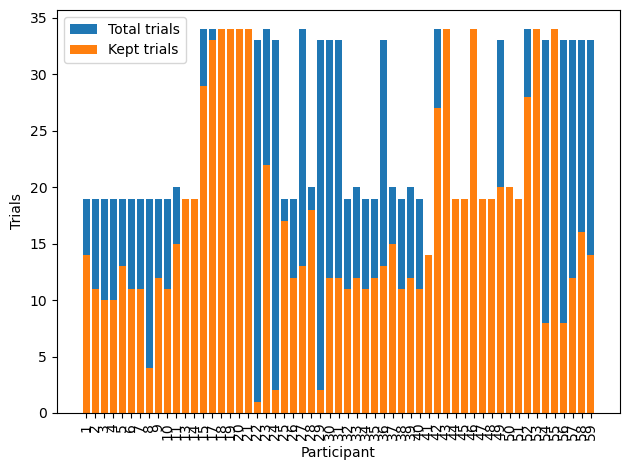

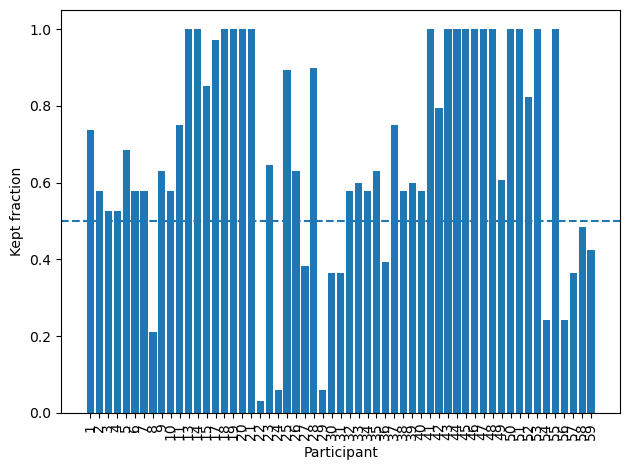

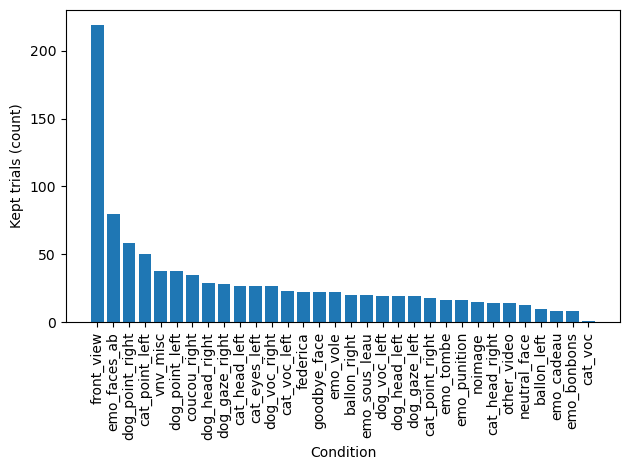

Saved:
 - ../data/qc_reports/qc_participant_keep_summary.csv
 - ../data/qc_reports/qc_log_with_participant_exclusion.csv
 - ../data/qc_reports/qc_kept_trials_participant_by_condition.csv


In [22]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def participant_exclusion_summary(
    qc_log: pd.DataFrame,
    keep_threshold: float = 0.50,
) -> pd.DataFrame:
    """
    qc_log must contain columns:
      - participant
      - trial
      - condition (optional but recommended)
      - exclude_trial (bool)
    Returns one row per participant with keep fraction and exclude flag.
    """
    df = qc_log.copy()

    # normalize types
    df["participant"] = pd.to_numeric(df["participant"], errors="coerce").astype("Int64")
    df["exclude_trial"] = df["exclude_trial"].astype(bool)

    # each trial counted once per participant (in case of duplicated rows)
    df = df.drop_duplicates(subset=["participant", "trial"])

    g = df.groupby("participant", dropna=True)
    out = g.agg(
        total_trials=("trial", "count"),
        excluded_trials=("exclude_trial", "sum"),
    ).reset_index()

    out["kept_trials"] = out["total_trials"] - out["excluded_trials"]
    out["kept_frac"] = out["kept_trials"] / out["total_trials"].replace(0, np.nan)
    out["exclude_participant"] = out["kept_frac"] < keep_threshold

    return out.sort_values("participant").reset_index(drop=True)


def plot_kept_trials_per_participant(part_summary: pd.DataFrame):
    """Bar plot: kept vs total per participant + threshold line (50%)."""
    df = part_summary.sort_values("participant").copy()
    x = np.arange(len(df))

    plt.figure()
    plt.bar(x, df["total_trials"].to_numpy(), label="Total trials")
    plt.bar(x, df["kept_trials"].to_numpy(), label="Kept trials")
    plt.xticks(x, df["participant"].astype(str).to_list(), rotation=90)
    plt.ylabel("Trials")
    plt.xlabel("Participant")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # keep fraction plot
    plt.figure()
    plt.bar(x, df["kept_frac"].to_numpy())
    plt.axhline(0.50, linestyle="--")
    plt.xticks(x, df["participant"].astype(str).to_list(), rotation=90)
    plt.ylabel("Kept fraction")
    plt.xlabel("Participant")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def trials_kept_by_condition_table(qc_log: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a participant x condition table (counts of KEPT trials).
    Useful to see if participants have very unbalanced kept data per condition.
    """
    df = qc_log.copy()
    df["participant"] = pd.to_numeric(df["participant"], errors="coerce").astype("Int64")
    df["exclude_trial"] = df["exclude_trial"].astype(bool)

    # unique trials
    df = df.drop_duplicates(subset=["participant", "trial"])

    kept = df.loc[~df["exclude_trial"]].copy()
    if "condition" not in kept.columns:
        raise ValueError("qc_log must contain a 'condition' column for this table.")

    tab = pd.pivot_table(
        kept,
        index="participant",
        columns="condition",
        values="trial",
        aggfunc="count",
        fill_value=0,
    )

    # add totals
    tab["KEPT_TOTAL"] = tab.sum(axis=1)
    return tab.sort_index()


def plot_kept_trials_by_condition(qc_log: pd.DataFrame):
    """
    Bar plot: total kept trials per condition (aggregated across participants).
    """
    df = qc_log.copy()
    df["exclude_trial"] = df["exclude_trial"].astype(bool)
    df = df.drop_duplicates(subset=["participant", "trial"])

    if "condition" not in df.columns:
        raise ValueError("qc_log must contain a 'condition' column for this plot.")

    kept = df.loc[~df["exclude_trial"]]
    counts = kept["condition"].value_counts().sort_values(ascending=False)

    plt.figure()
    plt.bar(counts.index.to_list(), counts.to_numpy())
    plt.xticks(rotation=90)
    plt.ylabel("Kept trials (count)")
    plt.xlabel("Condition")
    plt.tight_layout()
    plt.show()


def apply_participant_exclusion_to_qc_log(
    qc_log: pd.DataFrame,
    part_summary: pd.DataFrame,
) -> pd.DataFrame:
    """Adds participant-level exclusion columns back onto the trial-level log."""
    merged = qc_log.merge(
        part_summary[["participant", "kept_frac", "exclude_participant"]],
        on="participant",
        how="left",
    )
    return merged


# -----------------------
# Example usage
# -----------------------
if __name__ == "__main__":
    qc_path = Path("../data/qc_cleaning_log_right.csv")
    out_dir = Path("../data/qc_reports")
    out_dir.mkdir(parents=True, exist_ok=True)

    qc_log = pd.read_csv(qc_path)

    part_summary = participant_exclusion_summary(qc_log, keep_threshold=0.50)
    part_summary.to_csv(out_dir / "qc_participant_keep_summary.csv", index=False)

    qc_log_with_part = apply_participant_exclusion_to_qc_log(qc_log, part_summary)
    qc_log_with_part.to_csv(out_dir / "qc_log_with_participant_exclusion.csv", index=False)

    # Table: participant x condition (KEPT trial counts)
    tab = trials_kept_by_condition_table(qc_log)
    tab.to_csv(out_dir / "qc_kept_trials_participant_by_condition.csv")

    # Plots
    plot_kept_trials_per_participant(part_summary)
    plot_kept_trials_by_condition(qc_log)

    print("Saved:")
    print(" -", out_dir / "qc_participant_keep_summary.csv")
    print(" -", out_dir / "qc_log_with_participant_exclusion.csv")
    print(" -", out_dir / "qc_kept_trials_participant_by_condition.csv")

In [23]:
import pandas as pd

# Load trial-level QC log
qc = pd.read_csv("../data/qc_cleaning_log_right.csv")

# Sanity check
required = {"participant", "trial", "exclude_trial"}
missing = required - set(qc.columns)
if missing:
    raise ValueError(f"QC log missing columns: {missing}")

# Summarise per participant
participant_qc = (
    qc.groupby("participant")
      .agg(
          total_trials=("trial", "nunique"),
          kept_trials=("exclude_trial", lambda x: (~x).sum())
      )
      .reset_index()
)

participant_qc["kept_fraction"] = (
    participant_qc["kept_trials"] / participant_qc["total_trials"]
)

# Apply exclusion rule
KEEP_THRESHOLD = 0.50
participant_qc["exclude_participant"] = (
    participant_qc["kept_fraction"] < KEEP_THRESHOLD
)

# Save table for reporting
participant_qc.to_csv(
    "../data/qc_participant_exclusion_summary.csv",
    index=False
)

# Print quick summary
print("=== Participant exclusion summary ===")
print(participant_qc.sort_values("kept_fraction"))

print("\nExcluded participants:")
print(
    participant_qc.loc[
        participant_qc["exclude_participant"],
        ["participant", "kept_trials", "total_trials", "kept_fraction"]
    ]
)

=== Participant exclusion summary ===
    participant  total_trials  kept_trials  kept_fraction  exclude_participant
19           22            33            1       0.030303                 True
26           29            33            2       0.060606                 True
21           24            33            2       0.060606                 True
7             8            19            4       0.210526                 True
53           56            33            8       0.242424                 True
51           54            33            8       0.242424                 True
28           31            33           12       0.363636                 True
54           57            33           12       0.363636                 True
27           30            33           12       0.363636                 True
24           27            34           13       0.382353                 True
33           36            33           13       0.393939                 True
56           5